In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm


from scipy.io import loadmat
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d
from scipy import stats

%matplotlib widget

In [2]:
def fill_nan_bins(place_fields, axis=1):
    """Linearly interpolate over unvisited (NaN) position bins before smoothing.

    Unvisited bins are left as NaN when the place field is computed so that
    gaussian smoothing and peak-finding (argmax) aren't biased toward zero.
    """
    def interp_1d(row):
        nans = np.isnan(row)
        if not nans.any():
            return row
        if nans.all():
            return np.zeros_like(row)
        row = row.copy()
        x = np.arange(len(row))
        row[nans] = np.interp(x[nans], x[~nans], row[~nans])
        return row
    return np.apply_along_axis(interp_1d, axis, place_fields)

## Get the behavior

Loaded tracking data with 308232 timestamps and position shape (308232,) for x and (308232,) for y.


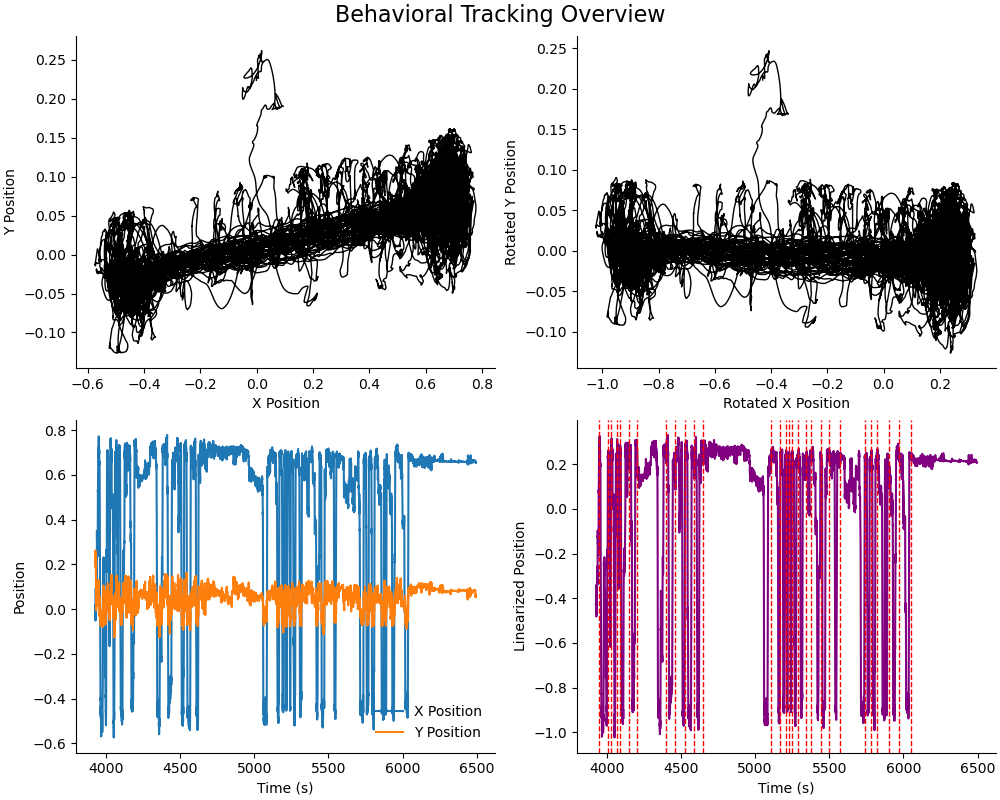

In [10]:
trial_starts = [3950, 4010, 4030, 4065, 4090, 4150, 4200, 4400, 4460, 4530, 4590, 4650, 5110, 5170, 5210, 5230, 5250, 5290, 5340, 5380, 5445, 5500, 5575, 5740, 5780, 5820, 5900, 5970, 6050] # trial starts in seconds

# Loading the position tracking data
tracking_file = '/mnt/home/srafilson/ceph/Bilat_R02_20251106/Bilat_R02_20251106_imec0.tracking.behavior.mat'
tracking = loadmat(tracking_file, squeeze_me=True)['tracking']

tracking_timestamps = tracking['timestamps'].item() # these are timestamps in seconds which are aligned to the raw spike times
position = tracking['position'].item()
x, y = np.array(position['x'].item()), np.array(position['y'].item())
print(f'Loaded tracking data with {len(tracking_timestamps)} timestamps and position shape {x.shape} for x and {y.shape} for y.')

# do PCA to linearize the position
positions = np.vstack((x, y)).T
positions_fit_pca = positions[500:-500]

pca = PCA(n_components=1)

# fit PCA only on trimmed data
pca.fit(positions_fit_pca)

# project ALL positions onto the learned axis
linearized_position = pca.transform(positions).flatten()

start_behavior_time = tracking_timestamps[0]
end_behavior_time = tracking_timestamps[-1]



fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

# --- Top: XY trajectory ---
axs[0,0].plot(x, y, color="black", linewidth=1)
axs[0,0].set_xlabel("X Position")
axs[0,0].set_ylabel("Y Position")



# --- Bottom: Position over time ---
axs[1,0].plot(tracking_timestamps, x, label="X Position", linewidth=1.5)
axs[1,0].plot(tracking_timestamps, y, label="Y Position", linewidth=1.5)
axs[1,0].set_xlabel("Time (s)")
axs[1,0].set_ylabel("Position")
axs[1,0].legend(frameon=False)

# --- Optional: linearized position over time
axs[1,1].plot(tracking_timestamps, linearized_position, color="purple", linewidth=1.5)
axs[1,1].set_xlabel("Time (s)")
axs[1,1].set_ylabel("Linearized Position")


# rotate the XY trajectory by the angle of the first principal component for better visualization
angle = np.arctan2(pca.components_[0, 1], pca.components_[0, 0])

rotation_matrix = np.array([
    [np.cos(-angle), -np.sin(-angle)],
    [np.sin(-angle),  np.cos(-angle)]
])

rotated_positions = (positions - positions.mean(axis=0)) @ rotation_matrix.T
axs[0,1].plot(rotated_positions[:,0], rotated_positions[:,1], color="black", linewidth=1)
axs[0,1].set_xlabel("Rotated X Position")
axs[0,1].set_ylabel("Rotated Y Position")
for start in trial_starts:
    axs[1,1].axvline(
        x=start,
        color="red",
        linestyle="--",
        linewidth=1
    )



sns.despine()
fig.suptitle("Behavioral Tracking Overview", fontsize=16)
plt.show()



## Load the spike count matrix

Resampled linearized position to match observations: (130600,) vs 130600 time bins.
Plotting data from 5160 to 5430 seconds, corresponding to indices 63600 to 77100 in the time_bins array.


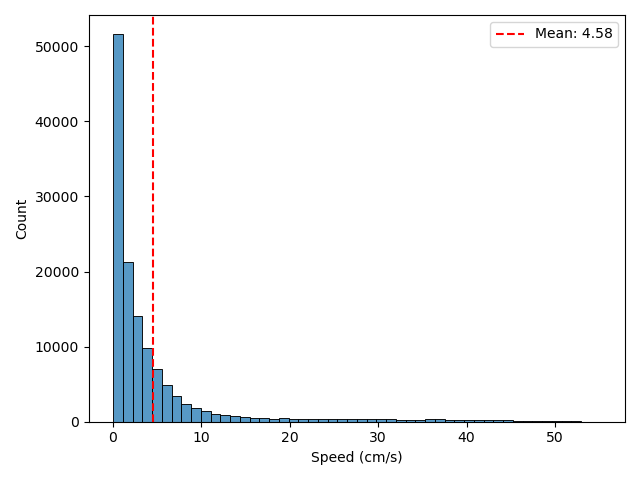

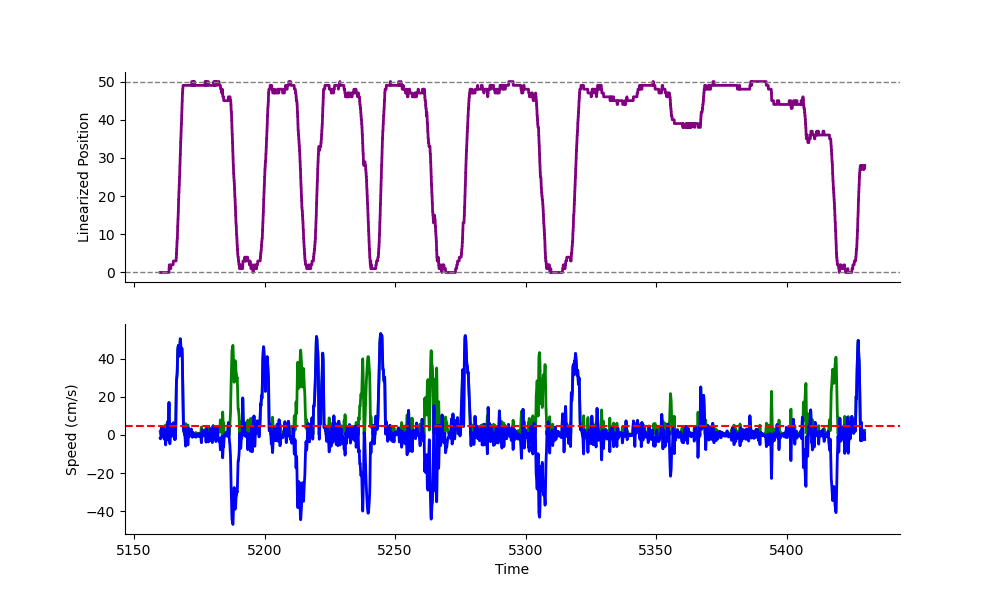

In [12]:
# Load the spike count data
data_path = '/mnt/home/srafilson/code/sequences/data/maze_clipped_spike_counts_pyr_only_Bilat_R02_20251106.npz'
data = np.load(data_path, allow_pickle=True)


# set the number of position bins
n_bins = 50


# get the observations and time bins from the data
observations = data["observations"]
time_bins = data["time_bins"]


# resample the linearized position so that each position corresponds to a time bin in the observations
# get the start and end time of the observations
start_time = time_bins[0]
end_time = time_bins[-1]

# resample the linearized position to match the number of time bins in the observations
linearized_position_resampled = np.interp(time_bins, tracking_timestamps, linearized_position)
print(f"Resampled linearized position to match observations: {linearized_position_resampled.shape} vs {observations.shape[0]} time bins.")

# bin the linearized position into discrete states (e.g., 10 bins)
linearized_position_binned = np.digitize(linearized_position_resampled, bins=np.linspace(np.percentile(linearized_position_resampled, 5), np.percentile(linearized_position_resampled, 85), n_bins))





# plot the linearized position and the speed 
start_sec = 5160
stop_sec = 5430

start = np.searchsorted(time_bins, start_sec)
stop = np.searchsorted(time_bins, stop_sec)
print(f"Plotting data from {start_sec} to {stop_sec} seconds, corresponding to indices {start} to {stop} in the time_bins array.")


velocity = gaussian_filter1d(np.gradient(linearized_position_resampled, time_bins), sigma=5) * 100
movement_direction = np.sign(velocity)
speed = np.abs(velocity)
mean_speed = np.mean(speed)

plt.figure()
sns.histplot(speed, bins=50)
plt.axvline(mean_speed, color='red', linestyle='--', label=f"Mean: {mean_speed:.2f}")
plt.legend()
plt.xlabel("Speed (cm/s)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(time_bins[start:stop], linearized_position_binned[start:stop], color='purple', linewidth=2)

# grey lines at top and bottom of the linearized position plot
ax[0].axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax[0].axhline(y=n_bins, color='gray', linestyle='--', linewidth=1)

ax[0].set_ylabel("Linearized Position")
ax[1].plot(time_bins[start:stop-1], speed[start:stop-1], color='green', linewidth=2)
ax[1].plot(time_bins[start:stop-1], velocity[start:stop-1], color='blue', linewidth=2)
ax[1].axhline(mean_speed, color='red', linestyle='--', label=f"Mean: {mean_speed:.2f}")
ax[1].set_ylabel("Speed (cm/s)")
ax[1].set_xlabel("Time")
sns.despine()
plt.show()

## Load the co-smoothing results

In [15]:
co_smoothing_dir = (
    "/mnt/home/srafilson/code/sequences/co-smoothing-data/pyr_only_20ms_N251"
)

params = np.load(
    os.path.join(co_smoothing_dir, "best_fit_params.npz"),
    allow_pickle=True,
)
A = params["A"]
B = params["B"]
pi = params["pi"]

print(A.shape, B.shape, pi.shape)

# Find and numerically sort held-out neuron directories
neurons = sorted(
    (
        name
        for name in os.listdir(co_smoothing_dir)
        if name.startswith("neuron")
    ),
    key=lambda name: int(name[7:]),
)

n_timepoints = len(linearized_position_binned)
n_neurons = len(neurons)

spike_count_predictions = np.empty(
    (n_timepoints, n_neurons),
    dtype=B.dtype,
)

for neuron_idx, neuron in tqdm(
    enumerate(neurons),
    total=n_neurons,
):
    states = np.load(
        os.path.join(co_smoothing_dir, neuron, "states.npy"),
        allow_pickle=False,
    ).astype(np.intp, copy=False)

    if states.shape[0] != n_timepoints:
        raise ValueError(
            f"{neuron}: states has {states.shape[0]} timepoints, "
            f"but expected {n_timepoints}."
        )

    # B has shape (n_states, n_neurons)
    spike_count_predictions[:, neuron_idx] = B[
        states,
        neuron_idx,
    ]








        

(251, 251) (251, 201) (251,)


  0%|          | 0/201 [00:00<?, ?it/s]

100%|██████████| 201/201 [00:02<00:00, 92.63it/s]


In [16]:
directions = [-1, 1]

n_neurons = len(neurons)
place_fields_expected = np.full((n_neurons, n_bins, len(directions)), np.nan)
place_fields_actual = np.full((n_neurons, n_bins, len(directions)), np.nan)

for d, direction in enumerate(directions):
    mask = (movement_direction == direction) & (speed > 3)
    linearized_position_masked = linearized_position_binned[mask]
    spike_count_predictions_masked = spike_count_predictions[mask, :]
    observations_masked = observations[mask, :]

    # compute the place field for each neuron using the expected spike counts
    for neuron in range(n_neurons):
        for bin_idx in range(1, n_bins+1):
            mask = linearized_position_masked == bin_idx
            if np.any(mask):
                place_fields_expected[neuron, bin_idx-1, d] = np.nanmean(spike_count_predictions_masked[mask, neuron])
            # else: leave as NaN (no visits to this bin) rather than biasing toward 0
    print(f"Computed place fields shape: {place_fields_expected.shape}")

    # compute the place field for each neuron using the actual spike counts
    for neuron in range(n_neurons):
        for bin_idx in range(1, n_bins+1):
            mask = linearized_position_masked == bin_idx
            if np.any(mask):
                place_fields_actual[neuron, bin_idx-1, d] = np.nanmean(observations_masked[mask, neuron])
            # else: leave as NaN (no visits to this bin) rather than biasing toward 0
    print(f"Computed place fields shape: {place_fields_actual.shape}")

# fill unvisited (NaN) bins by interpolation, then smooth the place fields
place_fields_actual_smoothed = gaussian_filter1d(fill_nan_bins(place_fields_actual), sigma=3, axis=1)
place_fields_expected_smoothed = gaussian_filter1d(fill_nan_bins(place_fields_expected), sigma=3, axis=1)


Computed place fields shape: (201, 50, 2)
Computed place fields shape: (201, 50, 2)
Computed place fields shape: (201, 50, 2)
Computed place fields shape: (201, 50, 2)


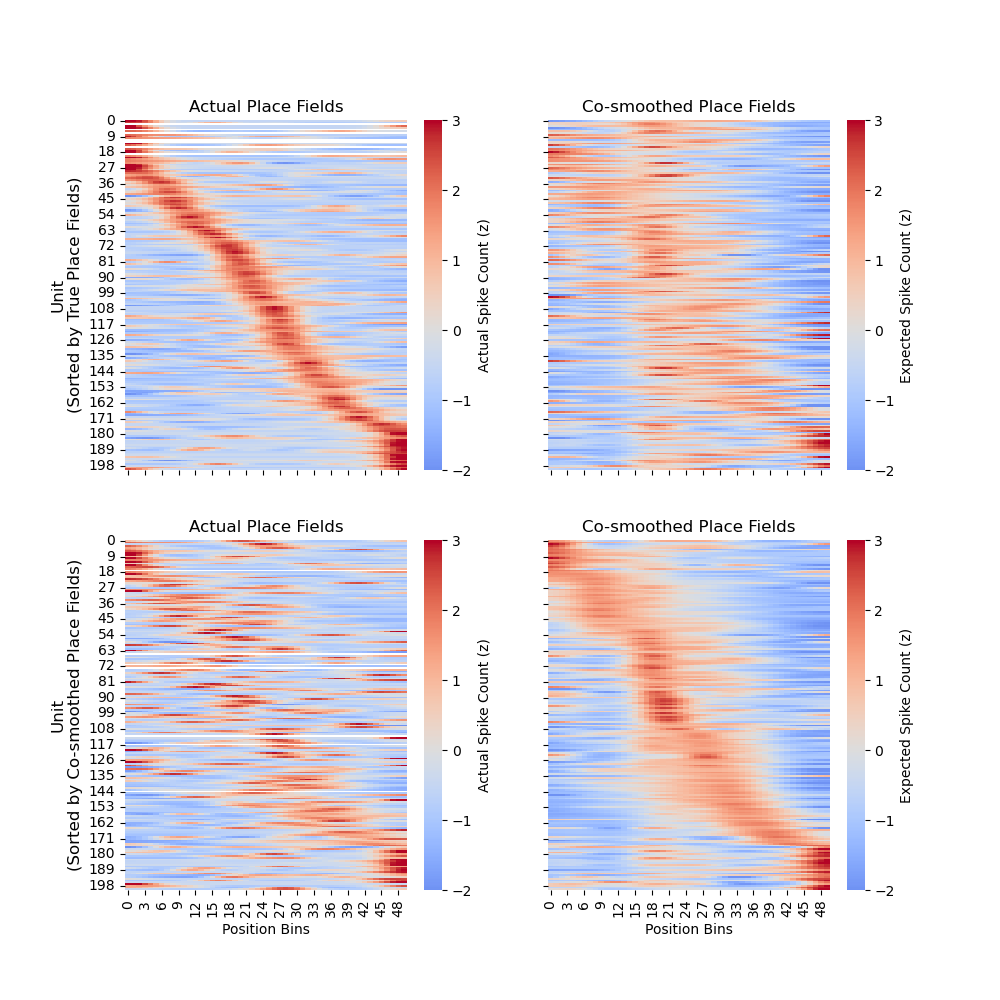

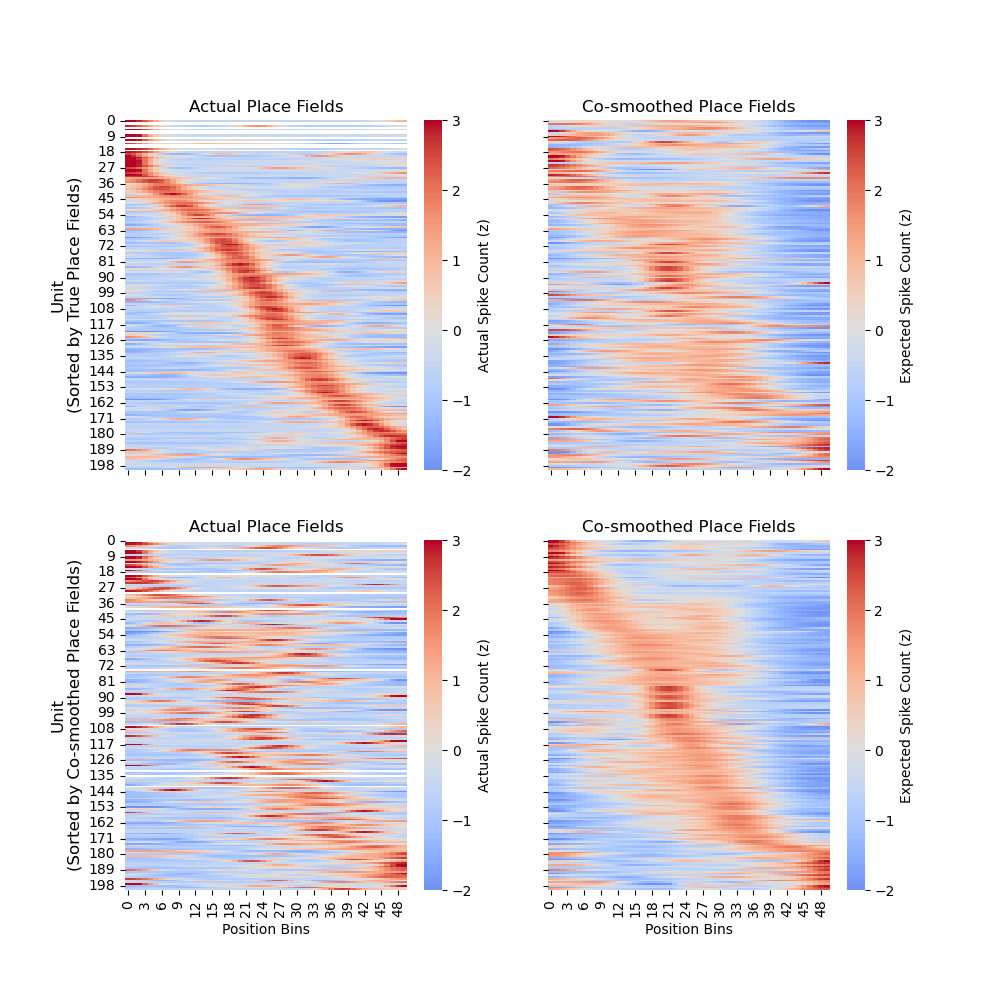

In [17]:
for d, direction in enumerate(directions):

    # plot the place fields heatmaps as a 2X2 grid
    fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)

    # first plot the true place fields sorted according to their peak
    peak_indices_actual = np.argmax(place_fields_actual_smoothed[:, :, d], axis=1)
    sorted_neuron_indices_actual = np.argsort(peak_indices_actual)
    place_fields_actual_sorted = place_fields_actual_smoothed[sorted_neuron_indices_actual, :, d]
    sns.heatmap(
        stats.zscore(place_fields_actual_sorted, axis=1),
        cmap='coolwarm',
        center=0,
        cbar_kws={'label': 'Actual Spike Count (z)'},
        ax=axs[0, 0],
        vmin = -2,
        vmax = 3
        
    )

    # now plot the expected place fields sorted according to their peak
    peak_indices_expected = np.argmax(place_fields_expected_smoothed[:, :, d], axis=1)
    sorted_neuron_indices_expected = np.argsort(peak_indices_expected)
    place_fields_expected_sorted = place_fields_expected_smoothed[sorted_neuron_indices_expected, :, d]
    sns.heatmap(
        stats.zscore(place_fields_expected_sorted, axis=1),
        cmap='coolwarm',
        center=0,
        cbar_kws={'label': 'Expected Spike Count (z)'},
        ax=axs[1, 1],
        vmin = -2,
        vmax = 3
    )

    # now plot the off diagonals as the palce field with other sorting
    sns.heatmap(
        stats.zscore(place_fields_actual_smoothed[sorted_neuron_indices_expected, :, d], axis=1),
        cmap='coolwarm',
        center=0,
        cbar_kws={'label': 'Actual Spike Count (z)'},
        ax=axs[1, 0],
        vmin = -2,
        vmax = 3
    )

    sns.heatmap(
        stats.zscore(place_fields_expected_smoothed[sorted_neuron_indices_actual, :, d], axis=1),
        cmap='coolwarm',
        center=0,
        cbar_kws={'label': 'Expected Spike Count (z)'},
        ax=axs[0, 1],
        vmin = -2,
        vmax = 3
    )

    axs[0,0].set_title('Actual Place Fields')
    axs[0,1].set_title('Co-smoothed Place Fields')
    axs[1,0].set_title('Actual Place Fields')
    axs[1,1].set_title('Co-smoothed Place Fields')

    axs[0,0].set_ylabel('Unit\n(Sorted by True Place Fields)', size=12)
    axs[1,0].set_ylabel('Unit\n(Sorted by Co-smoothed Place Fields)', size=12)

    axs[1,0].set_xlabel('Position Bins')
    axs[1,1].set_xlabel('Position Bins')

## Cross-Validate the place field sorting

In [25]:
# use 50-50 split cross validation to sort the place fields

cv_splits = [0, 1]
directions = [-1, 1]

n_neurons = len(neurons)
n_timestamps = linearized_position_binned.shape[0]
place_fields_expected = np.full((n_neurons, n_bins, len(directions), len(cv_splits)), np.nan)
place_fields_actual = np.full((n_neurons, n_bins, len(directions), len(cv_splits)), np.nan)

trial_intervals = [
    (np.searchsorted(time_bins, start), np.searchsorted(time_bins, trial_starts[i+1]))
    for i, start in enumerate(trial_starts[:-1])
]


for cv in cv_splits:
    for d, direction in enumerate(directions):

        # building the mask for the current direction, speed threshold, and cv_split
        mask = (movement_direction == direction) & (speed > 3)

        # apply the cross-validation split to the mask this is every other trial
        for i, (start, end) in enumerate(trial_intervals):
            if i % 2 != cv:
                mask[start:end] = False

        linearized_position_masked = linearized_position_binned[mask]
        spike_count_predictions_masked = spike_count_predictions[mask, :]
        observations_masked = observations[mask, :]

        # compute the place field for each neuron using the expected spike counts
        for neuron in range(n_neurons):
            for bin_idx in range(1, n_bins+1):
                bin_mask = linearized_position_masked == bin_idx
                if np.any(bin_mask):
                    place_fields_expected[neuron, bin_idx-1, d, cv] = np.nanmean(spike_count_predictions_masked[bin_mask, neuron])
                # else: leave as NaN (no visits to this bin) rather than biasing toward 0
        print(f"Computed place fields shape: {place_fields_expected.shape}")

        # compute the place field for each neuron using the actual spike counts
        for neuron in range(n_neurons):
            for bin_idx in range(1, n_bins+1):
                bin_mask = linearized_position_masked == bin_idx
                if np.any(bin_mask):
                    place_fields_actual[neuron, bin_idx-1, d, cv] = np.nanmean(observations_masked[bin_mask, neuron])
                # else: leave as NaN (no visits to this bin) rather than biasing toward 0
        print(f"Computed place fields shape: {place_fields_actual.shape}")

place_fields_actual_smoothed = gaussian_filter1d(fill_nan_bins(place_fields_actual), sigma=3, axis=1)
place_fields_expected_smoothed = gaussian_filter1d(fill_nan_bins(place_fields_expected), sigma=3, axis=1)

Computed place fields shape: (201, 50, 2, 2)
Computed place fields shape: (201, 50, 2, 2)
Computed place fields shape: (201, 50, 2, 2)
Computed place fields shape: (201, 50, 2, 2)
Computed place fields shape: (201, 50, 2, 2)
Computed place fields shape: (201, 50, 2, 2)
Computed place fields shape: (201, 50, 2, 2)
Computed place fields shape: (201, 50, 2, 2)


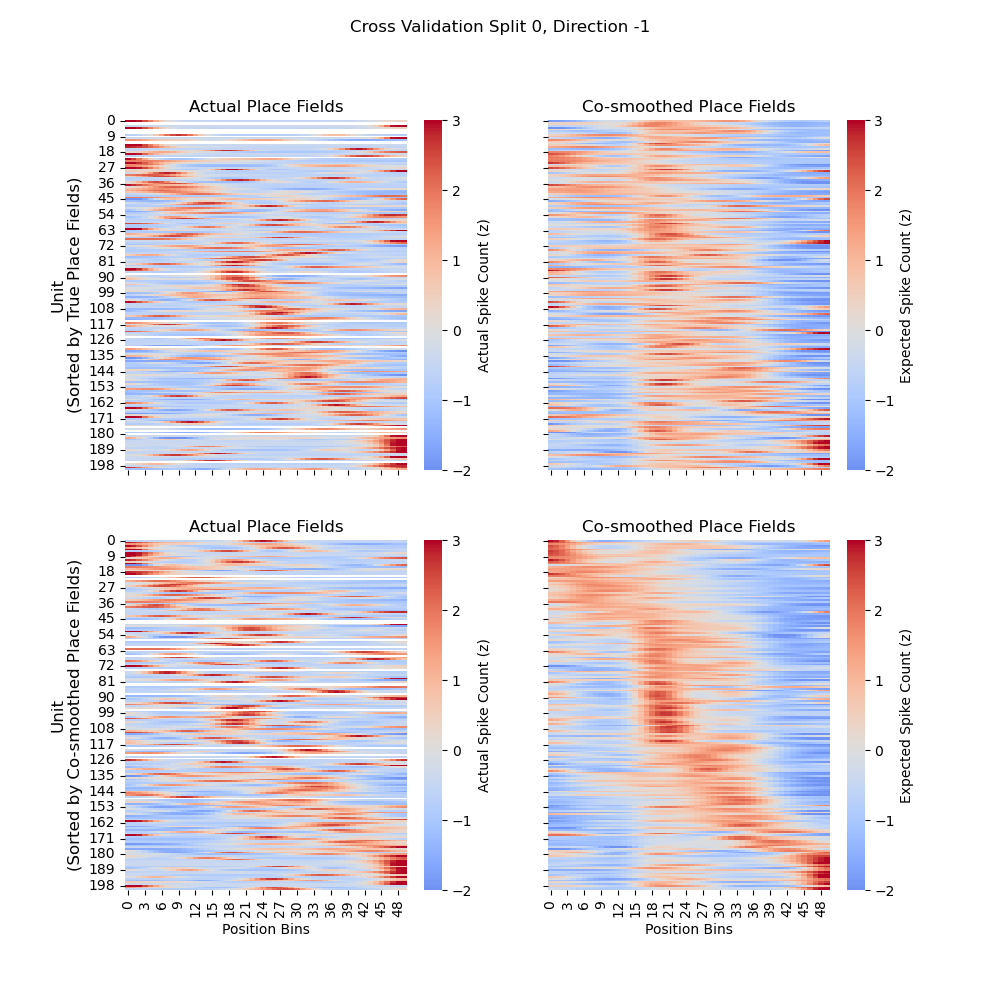

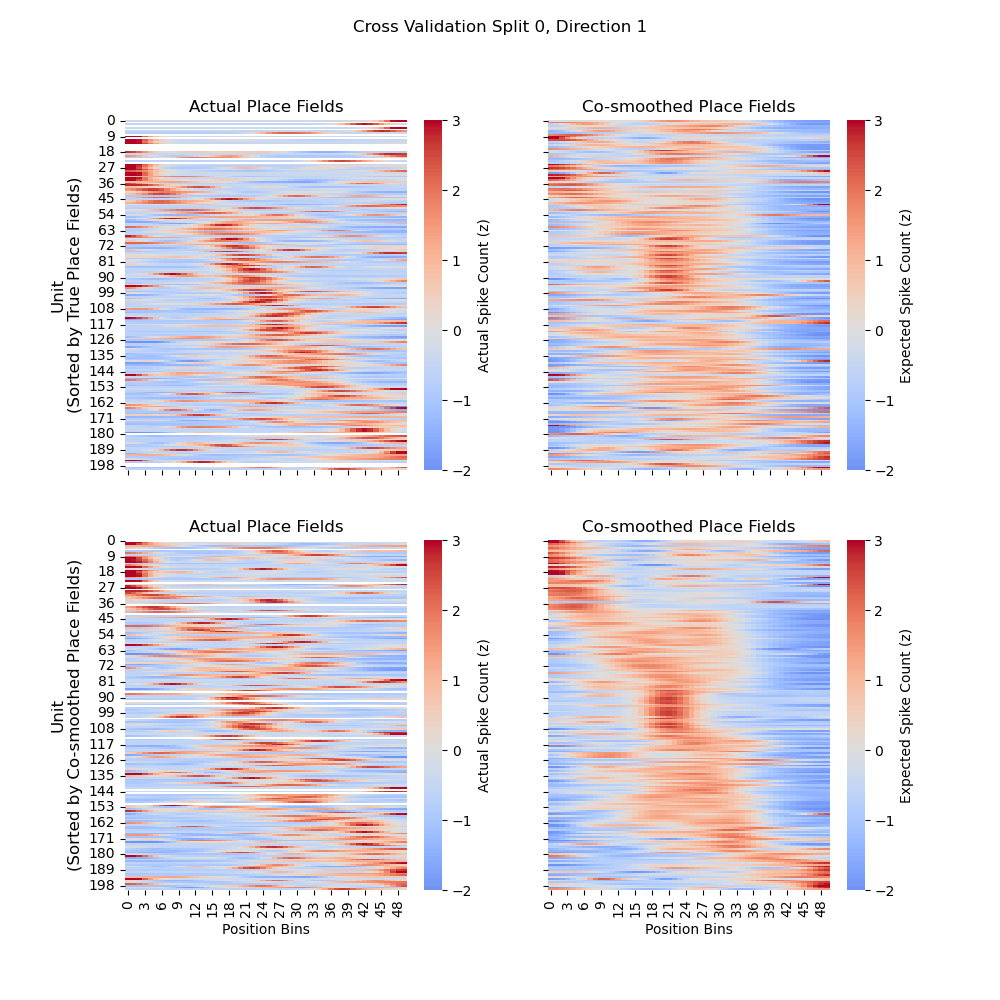

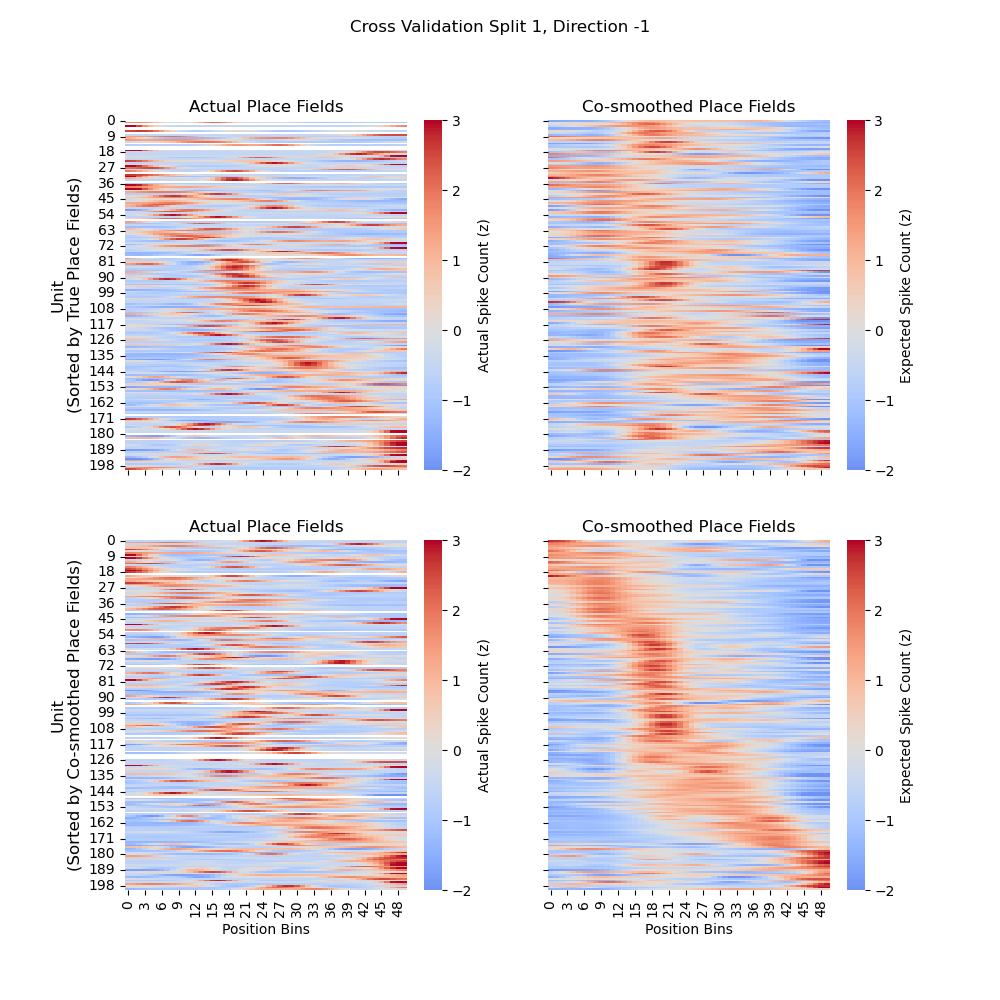

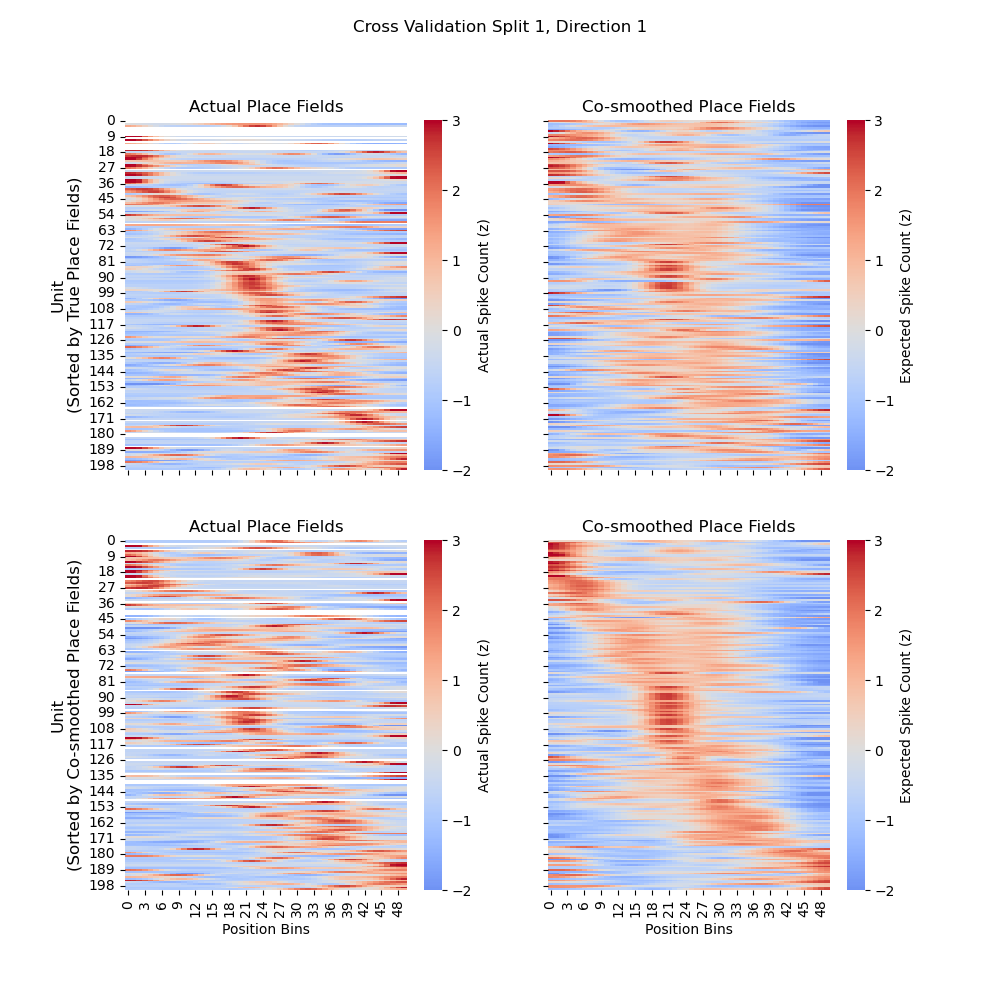

In [26]:
# plot the place fields for the cross validation splits sorting using the other split

for cv in cv_splits:
    for d, direction in enumerate(directions):

        if cv == 0:
            sort_ind = 1
        else:
            sort_ind = 0

        # plot the place fields heatmaps as a 2X2 grid
        fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)

        # first plot the true place fields sorted according to their peak
        peak_indices_actual = np.argmax(place_fields_actual_smoothed[:, :, d, sort_ind], axis=1)
        sorted_neuron_indices_actual = np.argsort(peak_indices_actual)
        place_fields_actual_sorted = place_fields_actual_smoothed[sorted_neuron_indices_actual, :, d, cv]
        sns.heatmap(
            stats.zscore(place_fields_actual_sorted, axis=1),
            cmap='coolwarm',
            center=0,
            cbar_kws={'label': 'Actual Spike Count (z)'},
            ax=axs[0, 0],
            vmin = -2,
            vmax = 3
            
        )

        # now plot the expected place fields sorted according to their peak
        peak_indices_expected = np.argmax(place_fields_expected_smoothed[:, :, d, sort_ind], axis=1)
        sorted_neuron_indices_expected = np.argsort(peak_indices_expected)
        place_fields_expected_sorted = place_fields_expected_smoothed[sorted_neuron_indices_expected, :, d, cv]
        sns.heatmap(
            stats.zscore(place_fields_expected_sorted, axis=1),
            cmap='coolwarm',
            center=0,
            cbar_kws={'label': 'Expected Spike Count (z)'},
            ax=axs[1, 1],
            vmin = -2,
            vmax = 3
        )

        # now plot the off diagonals as the palce field with other sorting
        sns.heatmap(
            stats.zscore(place_fields_actual_smoothed[sorted_neuron_indices_expected, :, d, cv], axis=1),
            cmap='coolwarm',
            center=0,
            cbar_kws={'label': 'Actual Spike Count (z)'},
            ax=axs[1, 0],
            vmin = -2,
            vmax = 3
        )

        sns.heatmap(
            stats.zscore(place_fields_expected_smoothed[sorted_neuron_indices_actual, :, d, cv], axis=1),
            cmap='coolwarm',
            center=0,
            cbar_kws={'label': 'Expected Spike Count (z)'},
            ax=axs[0, 1],
            vmin = -2,
            vmax = 3
        )

        axs[0,0].set_title('Actual Place Fields')
        axs[0,1].set_title('Co-smoothed Place Fields')
        axs[1,0].set_title('Actual Place Fields')
        axs[1,1].set_title('Co-smoothed Place Fields')

        axs[0,0].set_ylabel('Unit\n(Sorted by True Place Fields)', size=12)
        axs[1,0].set_ylabel('Unit\n(Sorted by Co-smoothed Place Fields)', size=12)

        axs[1,0].set_xlabel('Position Bins')
        axs[1,1].set_xlabel('Position Bins')

        plt.suptitle(f'Cross Validation Split {cv}, Direction {direction}')
        plt.show()
            